In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter

In [2]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)   # 防止数值溢出
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:
def one_hot(y, num_classes=10):
     # 1. 确保输入是numpy数组，转为整数类型，并展平为一维
    y = np.array(y).astype(int).flatten()

    # 2. 创建全零矩阵，形状为 (样本数, 类别数)
    out = np.zeros((len(y), num_classes))
    
     # 3. 使用高级索引将对应位置设为1
    out[np.arange(len(y)), y] = 1
    
    return out

In [4]:
def make_digit_image(digit, img_size=28, shift_range=3, blur=False, noise_level=0.0):
    # 黑底
    img = Image.new("L", (img_size, img_size), color=0)
    draw = ImageDraw.Draw(img)

    # 默认字体
    font = ImageFont.load_default()

    text = str(digit)

    # 计算文字大小
    bbox = draw.textbbox((0, 0), text, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    # 居中 + 随机偏移
    dx = np.random.randint(-shift_range, shift_range + 1)
    dy = np.random.randint(-shift_range, shift_range + 1)

    x = (img_size - text_w) // 2 + dx
    y = (img_size - text_h) // 2 + dy

    # 画白色数字
    draw.text((x, y), text, fill=255, font=font)

    # 可选轻微模糊
    if blur:
        img = img.filter(ImageFilter.GaussianBlur(radius=np.random.uniform(0.0, 0.8)))

    # 转成数组
    arr = np.array(img).astype(np.float32) / 255.0

    # 加少量噪声
    if noise_level > 0:
        noise = np.random.normal(0, noise_level, arr.shape)
        arr = arr + noise
        arr = np.clip(arr, 0, 1)

    return arr

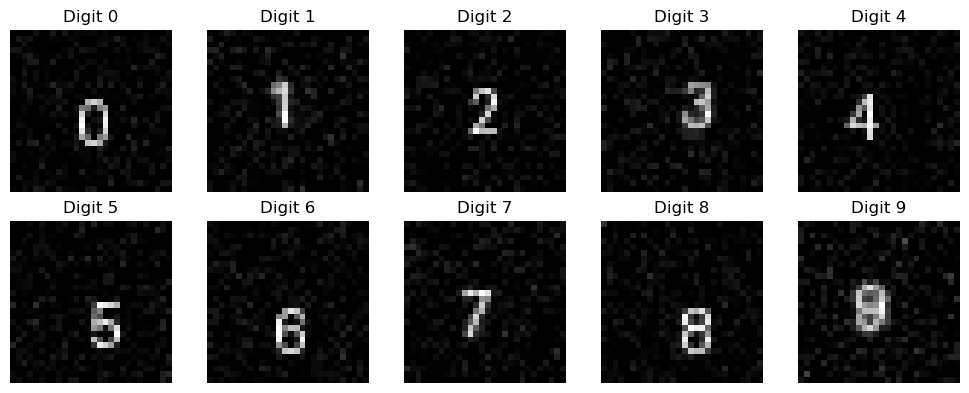

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for d in range(10):
    arr = make_digit_image(d, blur=True, noise_level=0.05)
    ax = axes[d // 5, d % 5]
    ax.imshow(arr, cmap="gray")
    ax.set_title(f"Digit {d}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
def build_dataset(samples_per_digit=200, img_size=28):
    X = []
    y = []

    for digit in range(10):
        for _ in range(samples_per_digit):
            arr = make_digit_image(
                digit,
                img_size=img_size,
                shift_range=3,
                blur=True,
                noise_level=0.08
            )
            X.append(arr.reshape(-1))   # 展平成 784 维
            y.append(digit)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=int)
    return X, y

In [7]:
X_train, y_train = build_dataset(samples_per_digit=300)
X_test, y_test = build_dataset(samples_per_digit=60)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (3000, 784)
y_train shape: (3000,)
X_test shape : (600, 784)
y_test shape : (600,)


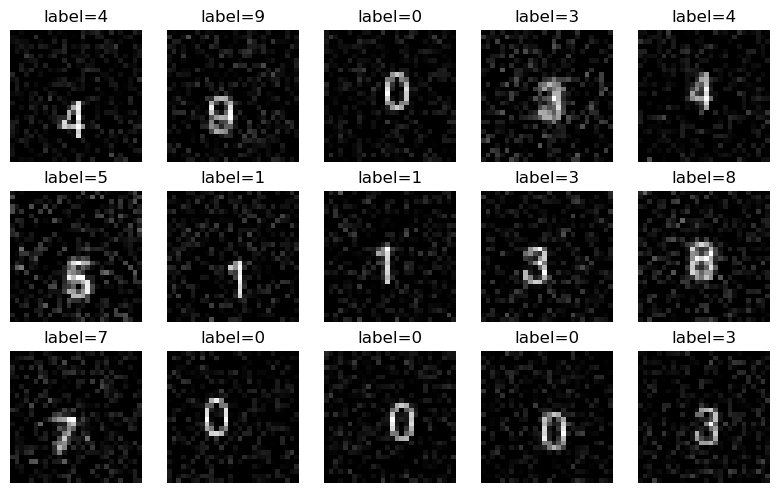

In [8]:
fig, axes = plt.subplots(3, 5, figsize=(8, 5))

indices = np.random.choice(len(X_train), 15, replace=False)

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(X_train[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"label={y_train[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
def init_params(input_dim=784, h1=128, h2=64, h3=32, output_dim=10, seed=42):
    np.random.seed(seed)
    params = {
        "W1": np.random.randn(input_dim, h1) * 0.01,
        "b1": np.zeros((1, h1)),
        "W2": np.random.randn(h1, h2) * 0.01,
        "b2": np.zeros((1, h2)),
        "W3": np.random.randn(h2, h3) * 0.01,
        "b3": np.zeros((1, h3)),
        "W4": np.random.randn(h3, output_dim) * 0.01,
        "b4": np.zeros((1, output_dim)),
    }
    return params

In [10]:
def forward(X, params):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)

    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2)

    Z3 = A2 @ params["W3"] + params["b3"]
    A3 = relu(Z3)

    Z4 = A3 @ params["W4"] + params["b4"]
    Y_hat = softmax(Z4)

    cache = {
        "X": X,
        "Z1": Z1, "A1": A1,
        "Z2": Z2, "A2": A2,
        "Z3": Z3, "A3": A3,
        "Z4": Z4, "Y_hat": Y_hat
    }
    return Y_hat, cache

In [11]:
def compute_loss(Y_hat, Y):
    m = Y.shape[0]
    eps = 1e-12
    return -np.sum(Y * np.log(Y_hat + eps)) / m

In [12]:
def backward(params, cache, Y):
    X = cache["X"]
    Z1, A1 = cache["Z1"], cache["A1"]
    Z2, A2 = cache["Z2"], cache["A2"]
    Z3, A3 = cache["Z3"], cache["A3"]
    Y_hat = cache["Y_hat"]

    m = X.shape[0]

    # 输出层
    dZ4 = (Y_hat - Y) / m
    dW4 = A3.T @ dZ4
    db4 = np.sum(dZ4, axis=0, keepdims=True)

    # 第3层
    dA3 = dZ4 @ params["W4"].T
    dZ3 = dA3 * relu_derivative(Z3)
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # 第2层
    dA2 = dZ3 @ params["W3"].T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # 第1层
    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    grads = {
        "dW1": dW1, "db1": db1,
        "dW2": dW2, "db2": db2,
        "dW3": dW3, "db3": db3,
        "dW4": dW4, "db4": db4,
    }
    return grads

In [13]:
def update(params, grads, lr=0.1):
    for k in ["W1", "b1", "W2", "b2", "W3", "b3", "W4", "b4"]:
        params[k] -= lr * grads["d" + k]
    return params

In [14]:
def predict(X, params):
    Y_hat, _ = forward(X, params)
    y_pred = np.argmax(Y_hat, axis=1)
    return y_pred, Y_hat

def accuracy(X, y, params):
    y_pred, _ = predict(X, params)
    return np.mean(y_pred == y)

In [15]:
def train(X_train, y_train, X_test, y_test, epochs=30, lr=0.1, batch_size=64):
    params = init_params(input_dim=X_train.shape[1])
    Y_train_oh = one_hot(y_train, 10)

    loss_history = []
    train_acc_history = []
    test_acc_history = []

    n = X_train.shape[0]

    for epoch in range(epochs):
        # 打乱数据
        indices = np.random.permutation(n)
        X_train_shuffled = X_train[indices]
        Y_train_oh_shuffled = Y_train_oh[indices]

        # mini-batch
        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_train_shuffled[start:end]
            Y_batch = Y_train_oh_shuffled[start:end]

            Y_hat, cache = forward(X_batch, params)
            grads = backward(params, cache, Y_batch)
            params = update(params, grads, lr)

        # 每个 epoch 结束后统计一次
        Y_hat_all, _ = forward(X_train, params)
        train_loss = compute_loss(Y_hat_all, Y_train_oh)
        train_acc = accuracy(X_train, y_train, params)
        test_acc = accuracy(X_test, y_test, params)

        loss_history.append(train_loss)
        train_acc_history.append(train_acc)
        test_acc_history.append(test_acc)

        print(f"epoch={epoch+1:2d}, loss={train_loss:.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

    return params, loss_history, train_acc_history, test_acc_history

In [ ]:
params, loss_history, train_acc_history, test_acc_history = train(
    X_train, y_train,
    X_test, y_test,
    epochs=1000,
    lr=0.1,
    batch_size=64
)

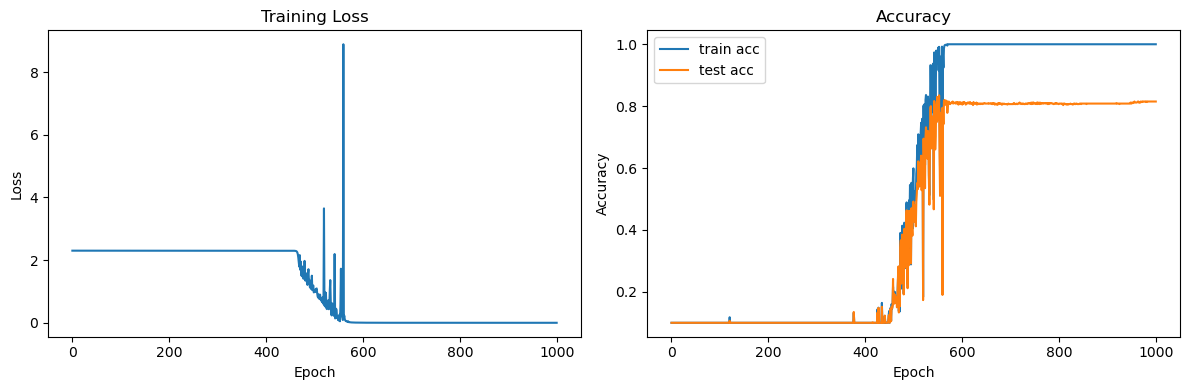

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label="train acc")
plt.plot(test_acc_history, label="test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
def show_predictions(params, num_samples=12):
    fig, axes = plt.subplots(3, 4, figsize=(8, 6))

    for ax in axes.flatten():
        true_digit = np.random.randint(0, 10)

        arr = make_digit_image(
            true_digit,
            img_size=28,
            shift_range=3,
            blur=True,
            noise_level=0.08
        )

        x = arr.reshape(1, -1)
        pred, probs = predict(x, params)

        ax.imshow(arr, cmap="gray")
        ax.set_title(f"true={true_digit}, pred={pred[0]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

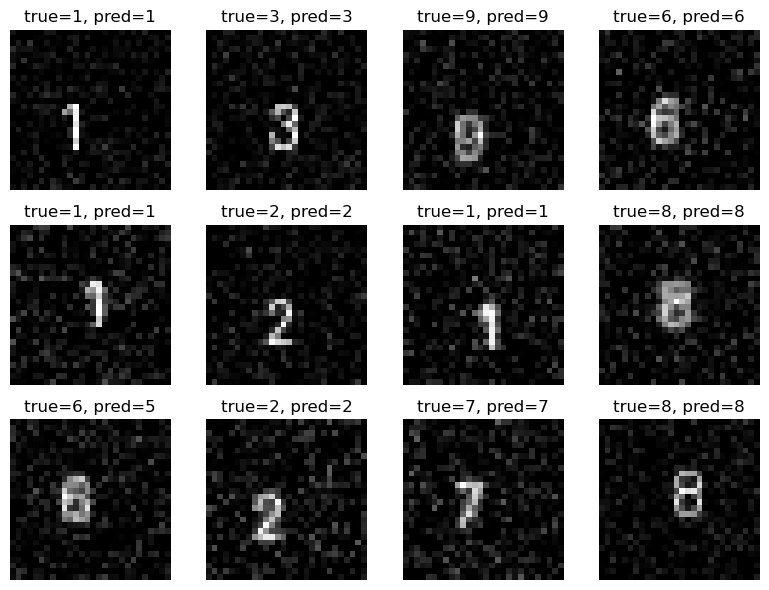

In [25]:
show_predictions(params, num_samples=12)